<a href="https://colab.research.google.com/github/PreciousAkpokighe/AI-ML-Training-course-professional-programme-with-Imperial-College-London/blob/main/Self_study_try_it_activity_15_2_Constructing_neural_networks_solution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Self-study try-it activity 15.2: Constructing neural networks


In this Self-Study Try-it Activity we will see how to construct a neural network.

In [1]:
import numpy as np
import matplotlib.pyplot as plt


### Construction of Neural Network

#### Input Layer
- The input layer receives the raw data as a vector.
- In this code, the input vector `x` has 3 elements: `[0.5, -1.2, 3.3]`.
- This layer simply passes the input data to the next layer without any computation.

#### Hidden Layer
- The hidden layer consists of 4 neurons.
- Each neuron computes a weighted sum of the input features plus a bias term:
  $$
  z_1 = W_1 \cdot x + b
  $$
  where:
  - \(W_1\) is a \(4 \times 3\) weight matrix,
  - \(b\) is a bias vector of length 4,
  - \(x\) is the input vector.
- The output of each neuron is then passed through the ReLU activation function, which introduces non-linearity:
 $$
  a_1 = \text{ReLU}(z_1) = \max(0, z_1)
 $$
- This activation zeroes out negative values, allowing the network to learn complex patterns.

#### Output Layer
- The output layer takes the 4 activated values from the hidden layer.
- It performs a weighted sum using weights \( W_2 \) (a \(1 \times 4\) matrix):
  $$
  \text{output} = W_2 \cdot a_1
  $$
- Produces a single scalar output value representing the network's prediction or response for the given input.

#### Activation Function: ReLU
- ReLU (Rectified Linear Unit) is defined as:
 $$
  \text{ReLU}(z) = \max(0, z)
 $$
- It keeps positive values as is and replaces negative ones with zero.
- This function introduces non-linearity to the network, enabling it to learn and model complex data patterns beyond linear relationships.


In [2]:
# Input vector
x = np.array([0.5, -1.2, 3.3])

# Weights and biases
W1 = np.array([[0.1, 0.2, 0.3],
               [0.4, 0.5, 0.6],
               [0.7, 0.8, 0.9],
               [1.0, 1.1, 1.2]])
b = np.array([0.1, -0.2, 0.3, -0.4])
W2 = np.array([[0.1, -0.1, 0.2, 0.3]])

def relu(z):
    return np.maximum(0, z)

z1 = W1.dot(x) + b
a1 = relu(z1)
output = W2.dot(a1)

print("Output:", output)


Output: [1.306]


The above neural network can be visualized as by using the code below

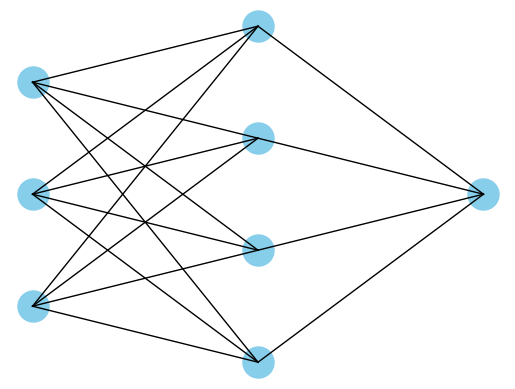

In [3]:


def draw_network():
    # Node positions
    layers = [3, 4, 1]
    v_spacing = 1
    h_spacing = 3
    for i, n_neurons in enumerate(layers):
        x = i * h_spacing
        for j in range(n_neurons):
            y = j * v_spacing - (n_neurons-1)*v_spacing/2
            plt.scatter(x, y, s=500, color='skyblue')
            if i > 0:
                prev_n = layers[i-1]
                for k in range(prev_n):
                    prev_y = k * v_spacing - (prev_n-1)*v_spacing/2
                    plt.plot([x-h_spacing, x], [prev_y, y], 'k-', lw=1)

    plt.axis('off')
    plt.show()

draw_network()


### To-Do:

Based on the neural network architecture shown in the diagram above:

1. Write the explicit funtional expression of the network, using matrix notation(eg. y = W2. RELU(W1 + b1) + b2)
2. Briefly explain the role and shape of each term (X, W1, b1, W2, b2).
3. Count the total number of trainable parameters in the network(number of weights and biases).

In [4]:

# Input vector (3-dim)
x = np.array([0.5, -1.2, 3.3])

# Weights: Input (3) -> Hidden (4)
W1 = np.random.randn(4, 3)     # Shape (4,3)
b1 = np.random.randn(4)        # Shape (4,)

# Weights: Hidden (4) -> Output (1)
W2 = np.random.randn(1, 4)     # Shape (1,4)
b2 = np.random.randn(1)        # Shape (1,)

# --- 2. ReLU activation function ---
def relu(z):
    return np.maximum(0, z)    # element-wise ReLU[1][3][5][6]

# --- 3. Forward pass (function composition) ---
def forward(x, W1, b1, W2, b2):
    # First linear transformation + bias
    z1 = np.dot(W1, x) + b1          # Shape: (4,)
    # Nonlinear activation (ReLU)
    a1 = relu(z1)                    # Shape: (4,)
    # Second linear transformation + output bias
    out = np.dot(W2, a1) + b2        # Shape: (1,)
    return out

# --- 4. Compute the output ---
output = forward(x, W1, b1, W2, b2)
print("Network output:", output)

# --- 5. Term identification (for documentation/reference) ---
print("--- Term identification ---")
print("x  : input vector (shape {})".format(x.shape))
print("W1 : weights input->hidden (shape {})".format(W1.shape))
print("b1 : biases of hidden layer (shape {})".format(b1.shape))
print("W2 : weights hidden->output (shape {})".format(W2.shape))
print("b2 : bias of output neuron (shape {})".format(b2.shape))


Network output: [9.02931399]
--- Term identification ---
x  : input vector (shape (3,))
W1 : weights input->hidden (shape (4, 3))
b1 : biases of hidden layer (shape (4,))
W2 : weights hidden->output (shape (1, 4))
b2 : bias of output neuron (shape (1,))


### To-Do:
Write the explicit functional expression describing the following network architecture displayed in the diagram above. You can assume that the activation function from layer 2 to layer 3 is of ReLU type. Moreover, assume that there is a bias term connecting to each layer. Count the number of weights in this architecture.

In [5]:
from graphviz import Digraph

dot = Digraph(format='png')

# Input layer nodes
for i in range(3):
    dot.node(f'x{i+1}', f'x{i+1}', shape='circle', style='filled', color='lightblue')

# Bias node for input layer to hidden layer
dot.node('b1', 'b1', shape='circle', style='filled', color='gray')

# Hidden layer nodes
for j in range(4):
    dot.node(f'h{j+1}', f'h{j+1}', shape='circle', style='filled', color='orange')

# Bias node for hidden layer to output node
dot.node('b2', 'b2', shape='circle', style='filled', color='gray')

# Output node
dot.node('y', 'output', shape='circle', style='filled', color='lightgreen')

# Connections: input -> hidden
for i in range(3):
    for j in range(4):
        dot.edge(f'x{i+1}', f'h{j+1}')

# Connect bias b1 to all hidden nodes
for j in range(4):
    dot.edge('b1', f'h{j+1}')

# Connections: hidden -> output
for j in range(4):
    dot.edge(f'h{j+1}', 'y')

# Connect bias b2 to output node
dot.edge('b2', 'y')

# Render and view graph
dot.render('nn_with_bias', view=True)



'nn_with_bias.png'

In [6]:
### Based on the above given below, print the weights and biases.

In [7]:
input_size = 3
hidden_size = 4
output_size = 1

# Weights
weights_input_hidden = input_size * hidden_size  # 12
weights_hidden_output = hidden_size * output_size  # 4

# Biases
bias_hidden = hidden_size  # 4
bias_output = output_size  # 1

total_weights = weights_input_hidden + weights_hidden_output
total_biases = bias_hidden + bias_output
total_params = total_weights + total_biases

print(f"Weights from input to hidden: {weights_input_hidden}")
print(f"Biases for hidden layer: {bias_hidden}")
print(f"Weights from hidden to output: {weights_hidden_output}")
print(f"Bias for output layer: {bias_output}")
print(f"Total weights: {total_weights}")
print(f"Total biases: {total_biases}")
print(f"Total weights and biases: {total_params}")


Weights from input to hidden: 12
Biases for hidden layer: 4
Weights from hidden to output: 4
Bias for output layer: 1
Total weights: 16
Total biases: 5
Total weights and biases: 21
